# 範例2. 使用HOG、滑動視窗、影像金字塔及SVM進行物件偵測

In [1]:
# Scikit-Image 的範例
# 載入套件
from itertools import chain
from typing import Iterator, cast

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from skimage import (
    color,
    data,
    feature,  # To use skimage.feature.hog()
    transform,
)
from skimage.feature import hog
from sklearn.datasets import fetch_lfw_people
from sklearn.feature_extraction.image import PatchExtractor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.utils import Bunch

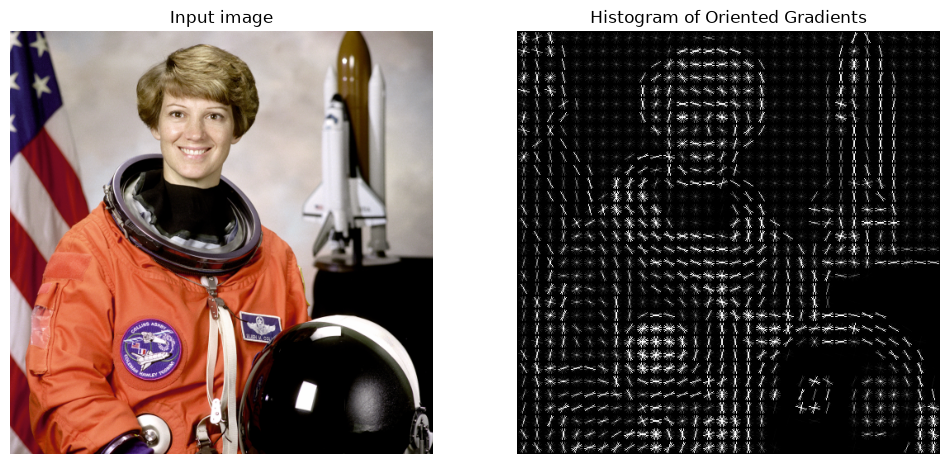

In [2]:
# 測試圖片
image = data.astronaut()

# 取得圖片的 hog
fd, hog_image = hog(
    image, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=True, channel_axis=-1
)

# 原圖與 hog圖比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# 調整對比，讓顯示比較清楚
hog_image_rescaled = np.clip(hog_image, 0, 10) / 10

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [3]:
# 收集正樣本 (positive set)
# 使用 scikit-learn 的人臉資料集
faces = cast(Bunch, fetch_lfw_people())
positive_patches = faces.images
positive_patches.shape

(13233, 62, 47)

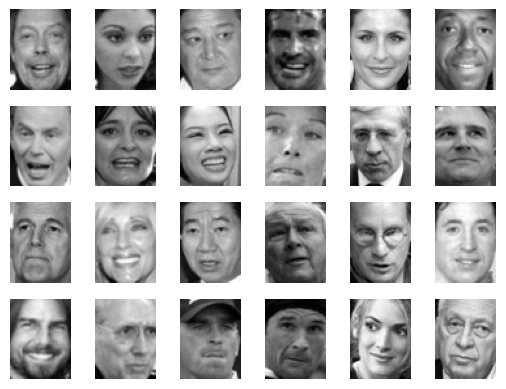

In [4]:
# 顯示正樣本部份圖片
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(positive_patches[500 * i], cmap='gray')
    axi.axis('off')

In [5]:
# 收集負樣本 (negative set)
# 使用 Scikit-Image 的非人臉資料
# 部份圖片（text、coins、moon、page、clock）本身已是灰階，只需對彩色圖片轉灰階
imgs_to_use = ['hubble_deep_field', 'text', 'coins', 'moon', 'page', 'clock', 'coffee', 'chelsea', 'horse']
raw_images = [getattr(data, name)() for name in imgs_to_use]
images = [color.rgb2gray(img) if img.ndim == 3 else img for img in raw_images]
len(images)

9

In [6]:
# 將負樣本轉換為不同的尺寸
# 轉換為不同的尺寸
def extract_patches(
    img: np.ndarray, N: int, scale: float = 1.0, patch_size: tuple[int, ...] = positive_patches[0].shape
) -> np.ndarray:
    extracted_patch_size = tuple((scale * np.array(patch_size)).astype(int))
    # PatchExtractor：產生不同尺寸的圖像
    extractor = PatchExtractor(patch_size=extracted_patch_size, max_patches=N, random_state=0)
    patches = extractor.transform(img[np.newaxis])
    if scale != 1:
        patches = np.array([transform.resize(patch, patch_size) for patch in patches])
    return patches


# 產生 27000 筆圖像
negative_patches = np.vstack([extract_patches(im, 1000, scale) for im in images for scale in [0.5, 1.0, 2.0]])
negative_patches.shape

(27000, 62, 47)

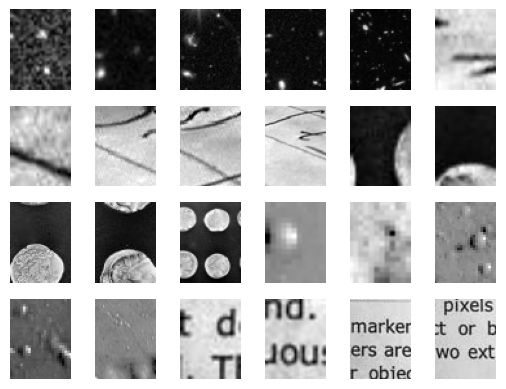

In [7]:
# 顯示部份負樣本
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(negative_patches[600 * i], cmap='gray')
    axi.axis('off')

In [8]:
# 合併正樣本與負樣本
X_train = np.array([feature.hog(im) for im in chain(positive_patches, negative_patches)])
y_train = np.zeros(X_train.shape[0])
y_train[: positive_patches.shape[0]] = 1

In [9]:
# 使用 SVM 作二分類的訓練
# C為矯正過度擬合強度的倒數，使用 GridSearchCV 尋求最佳參數值
grid = GridSearchCV(LinearSVC(dual=False), {'C': [1.0, 2.0, 4.0, 8.0]}, cv=3)
grid.fit(X_train, y_train)
grid.best_score_

np.float64(0.9882931921556931)

In [10]:
# C 最佳參數值
grid.best_params_

{'C': 1.0}

In [11]:
# 依最佳參數值再訓練一次
model = grid.best_estimator_
model.fit(X_train, y_train)

,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

(np.float64(-0.5), np.float64(99.5), np.float64(119.5), np.float64(-0.5))

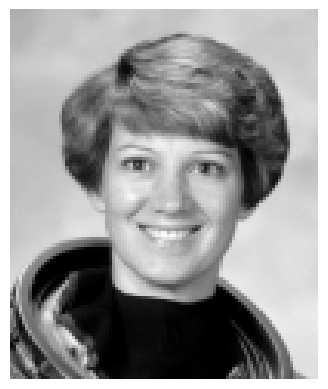

In [12]:
# 取新圖像測試
test_img = data.astronaut()
test_img = color.rgb2gray(test_img)
test_img = transform.rescale(test_img, 0.5)
test_img = test_img[:120, 60:160]

plt.imshow(test_img, cmap='gray')
plt.axis('off')

In [13]:
# 滑動視窗函數
def sliding_window(
    img: np.ndarray,
    patch_size: tuple[int, ...] = positive_patches[0].shape,
    istep: int = 2,
    jstep: int = 2,
    scale: float = 1.0,
) -> Iterator[tuple[tuple[int, int], np.ndarray]]:
    Ni, Nj = (int(scale * s) for s in patch_size)
    for i in range(0, img.shape[0] - Ni, istep):
        for j in range(0, img.shape[1] - Ni, jstep):
            patch = img[i : i + Ni, j : j + Nj]
            if scale != 1:
                patch = np.asarray(transform.resize(patch, patch_size))
            yield (i, j), patch

In [14]:
# 使用滑動視窗計算每一視窗的 Hog
indices, patches = zip(*sliding_window(test_img))
patches_hog = np.array([feature.hog(patch) for patch in patches])

# 辨識每一視窗
labels = model.predict(patches_hog)
labels.sum()  # 偵測到的總數

np.float64(51.0)

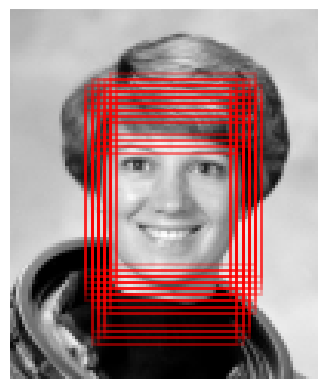

In [15]:
# 將每一個偵測到的視窗顯示出來
fig, ax = plt.subplots()
ax.imshow(test_img, cmap='gray')
ax.axis('off')

# 取得左上角座標
Ni, Nj = positive_patches[0].shape
indices = np.array(indices)

# 顯示
for i, j in indices[labels == 1]:
    ax.add_patch(Rectangle((j, i), Nj, Ni, edgecolor='red', alpha=0.3, lw=2, facecolor='none'))

In [16]:
patches_hog.shape

(551, 1215)

In [17]:
candidate_patches = patches_hog[labels == 1]
candidate_patches.shape

(51, 1215)

##  Non-Maximum Suppression演算法
#### https://www.pyimagesearch.com/2014/11/17/non-maximum-suppression-object-detection-python/

In [18]:
# Non-Maximum Suppression演算法 by Felzenszwalb et al.
# boxes：所有候選的視窗，overlapThresh：視窗重疊的比例門檻
def non_max_suppression_slow(boxes: np.ndarray, overlapThresh: float = 0.5) -> np.ndarray | list:
    if len(boxes) == 0:
        return []

    pick = []  # 儲存篩選的結果
    x1 = boxes[:, 0]  # 取得候選的視窗的左/上/右/下 座標
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    # 計算候選視窗的面積
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)  # 依視窗的底Y座標排序

    # 比對重疊比例
    while len(idxs) > 0:
        # 最後一筆
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        suppress = [last]

        # 比對最後一筆與其他視窗重疊的比例
        for pos in range(0, last):
            j = idxs[pos]

            # 取得所有視窗的涵蓋範圍
            xx1 = max(x1[i], x1[j])
            yy1 = max(y1[i], y1[j])
            xx2 = min(x2[i], x2[j])
            yy2 = min(y2[i], y2[j])
            w = max(0, xx2 - xx1 + 1)
            h = max(0, yy2 - yy1 + 1)

            # 計算重疊比例
            overlap = float(w * h) / area[j]

            # 如果大於門檻值，則儲存起來
            if overlap > overlapThresh:
                suppress.append(pos)

        # 刪除合格的視窗，繼續比對
        idxs = np.delete(idxs, suppress)

    # 傳回合格的視窗
    return boxes[pick]

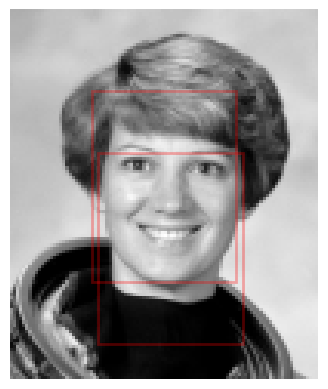

In [19]:
# 使用 Non-Maximum Suppression演算法，剔除多餘的視窗。
candidate_boxes = []
for i, j in indices[labels == 1]:
    candidate_boxes.append([j, i, Nj, Ni])
final_boxes = non_max_suppression_slow(np.array(candidate_boxes).reshape(-1, 4))

# 將每一個合格的視窗顯示出來
fig, ax = plt.subplots()
ax.imshow(test_img, cmap='gray')
ax.axis('off')

# 顯示
for i, j, Ni, Nj in final_boxes:
    ax.add_patch(Rectangle((i, j), Ni, Nj, edgecolor='red', alpha=0.3, lw=2, facecolor='none'))